# Final Project

Ok, so today we'll be working with the transactions, product, and hh_demographic tables in the project_data folder.

* First, read in the transactions data.

* Read in the only columns `household_key`, `BASKET_ID`, `DAY`, `PRODUCT_ID`, `QUANTITY`, and `SALES_VALUE`.

* Convert `DAY`, `QUANTITY`, and `PRODUCT_ID` to the smallest appropriate integer types.


In [2]:
import pandas as pd
import numpy as np

In [3]:
cols = ['household_key', 'BASKET_ID', 'DAY', 'PRODUCT_ID', 'QUANTITY','SALES_VALUE']

In [4]:
transactions = pd.read_csv(r"C:\Users\SophiaDeva\OneDrive - Xalient Holdings Limited\Data Notes\personal docs\data-analysis-with-python-pandas_course_resources\Pandas Course Resources\project_data\project_transactions.csv",header = 0,usecols = cols,dtype = {'DAY':'Int16', 'PRODUCT_ID':'Int32', 'QUANTITY':'Int32'})

In [5]:
transactions.head()

,household_key,BASKET_ID,DAY,PRODUCT_ID,QUANTITY,SALES_VALUE
0,1364,26984896261,1,842930,1,2.19
1,1364,26984896261,1,897044,1,2.99
2,1364,26984896261,1,920955,1,3.09
3,1364,26984896261,1,937406,1,2.50
4,1364,26984896261,1,981760,1,0.60


In [6]:
# Use the following snippet to create a Date Column.

transactions = (
    transactions
    .assign(date = (pd.to_datetime("2016", format='%Y') 
                    + pd.to_timedelta(transactions["DAY"].sub(1).astype(str) + " days"))
           )
    .drop(["DAY"], axis=1)
)

## TIME BASED ANALYSIS

* Plot the sum of sales by month. Are sales growing over time?
* Next, plot the same series after filtering down to dates April 2016 and October 2017.
* Then, plot the sum of monthly sales in 2016 vs the monthly sales 2017.
* Finally, plot total sales by day of week.

<Axes: xlabel='date'>

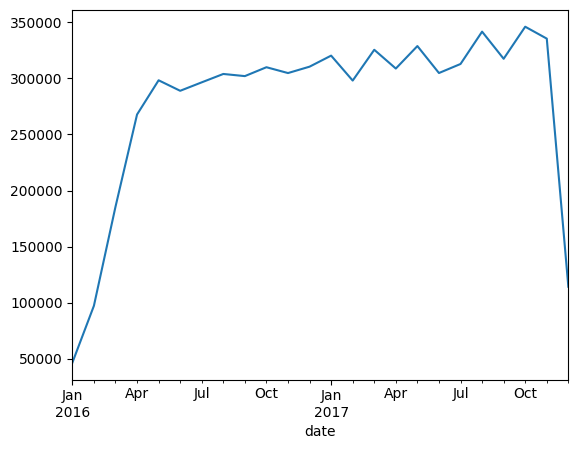

In [7]:
transactions.set_index('date').loc[:,'SALES_VALUE'].resample('ME').sum().plot()

<Axes: xlabel='date'>

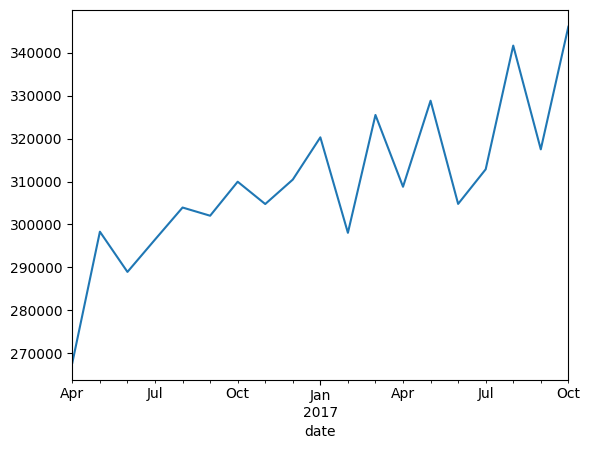

In [8]:
transactions.set_index('date').sort_index().loc['2016-04':'2017-10','SALES_VALUE'].resample('ME').sum().plot()

<Axes: xlabel='date'>

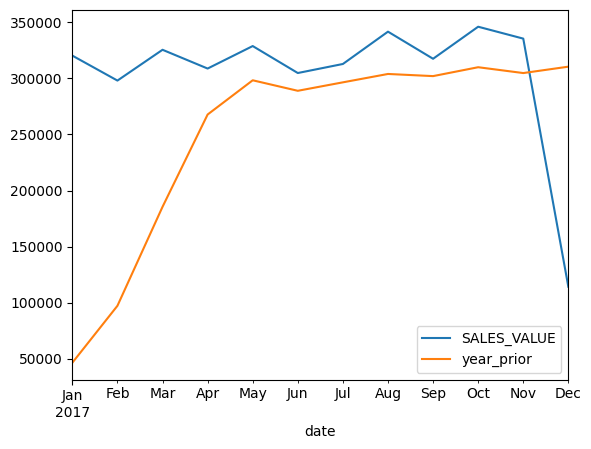

In [ ]:
plot3 = (transactions
 .set_index("date")
 .loc[:, ["SALES_VALUE"]]
 .resample("ME")
 .sum()
 .assign(year_prior = lambda x: x["SALES_VALUE"].shift(12))
 .loc["2017"]
 .plot(title = 'Monthly Sales Comparision 2016 vs 2017')
)
plot3

<Axes: xlabel='date'>

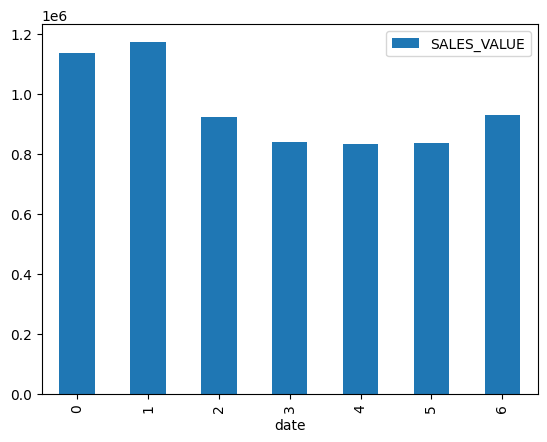

In [10]:
transactions.groupby(transactions['date'].dt.dayofweek).agg({'SALES_VALUE':'sum'}).plot.bar()

# DEMOGRAPHICS

* Read in the `hh_demographic.csv` file, but only the columns `AGE_DESC`, `INCOME_DESC`, `household_key`, and `HH_COMP_DESC`. Convert the appropriate columns to the category dtype.


* Then group the transactions table by household_id, and calculate the sum of SALES VALUE by household.


* Once you've done that, join the demographics DataFrame to the aggregated transactions table. Since we're interested in analyzing the demographic data we have, make sure not to include rows from transactions that don't match.


* Plot the sum of sales by age_desc and income_desc (in separate charts).


* Then, create a pivot table of the mean household sales by `AGE_DESC` and `HH_COMP_DESC`. Which of our demographics have the highest average sales?


In [11]:
demographic = pd.read_csv(r"C:\Users\SophiaDeva\OneDrive - Xalient Holdings Limited\Data Notes\personal docs\data-analysis-with-python-pandas_course_resources\Pandas Course Resources\project_data\hh_demographic.csv"
,header = 0,usecols = ['AGE_DESC','INCOME_DESC','HH_COMP_DESC','household_key']
,dtype = {'AGE_DESC':'category','INCOME_DESC':'category','HH_COMP_DESC':'category'}

)

In [12]:
transaction_household_Sales = transactions.groupby('household_key').agg({'SALES_VALUE':'sum'})
transaction_household_Sales.head()

,SALES_VALUE
household_key,
1,4330.16
2,1954.34
3,2653.21
4,1200.11
5,779.06


In [13]:
combined_df = transaction_household_Sales.merge(demographic,how='inner',left_on='household_key',right_on='household_key')
combined_df

,household_key,SALES_VALUE,AGE_DESC,INCOME_DESC,HH_COMP_DESC
0,1,4330.16,65+,35-49K,2 Adults No Kids
1,7,3400.05,45-54,50-74K,2 Adults No Kids
2,8,5534.97,25-34,25-34K,2 Adults Kids
3,13,13190.92,25-34,75-99K,2 Adults Kids
4,16,1512.02,45-54,50-74K,Single Female
...,...,...,...,...,...
663,2087,7832.74,45-54,100-124K,Unknown
664,2088,4905.71,25-34,35-49K,Single Female
665,2092,2290.54,35-44,Under 15K,1 Adult Kids
666,2094,3055.52,45-54,50-74K,2 Adults No Kids


<Axes: xlabel='AGE_DESC'>

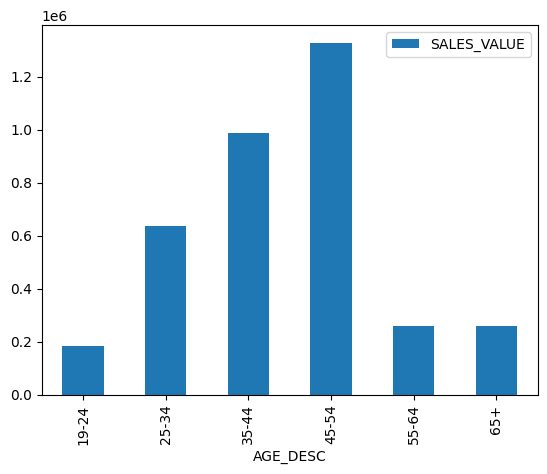

In [14]:
combined_df.groupby('AGE_DESC').agg({'SALES_VALUE':'sum'}).plot.bar()

<Axes: title={'center': 'Income Category by Sales'}, xlabel='Income Group', ylabel='sales'>

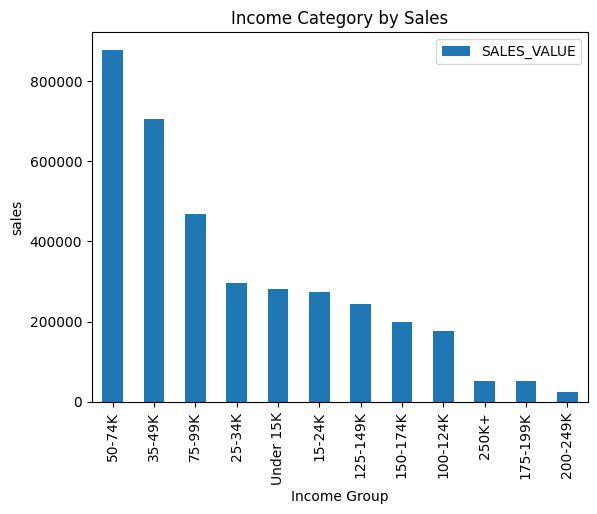

In [37]:
plot2 = combined_df.groupby('INCOME_DESC').agg({'SALES_VALUE':'sum'}).sort_values('SALES_VALUE',ascending=False).plot.bar(title = 'Income Category by Sales',xlabel = 'Income Group',ylabel = 'sales');
plot2

In [32]:
plot2.figure.savefig('Income Category by Sales.png',bbox_inches = 'tight')

In [40]:
heatmap_age = (combined_df.pivot_table(index='AGE_DESC',columns='HH_COMP_DESC',values='SALES_VALUE',aggfunc='mean',margins=True)
.style.background_gradient(cmap='RdYlGn',axis = None))

heatmap_age

HH_COMP_DESC,1 Adult Kids,2 Adults Kids,2 Adults No Kids,Single Female,Single Male,Unknown,All
AGE_DESC,,,,,,,
19-24,7268.796667,5428.945000,4020.800000,4576.095556,3216.835000,4911.275000,4692.077692
25-34,5512.196875,5753.973514,5638.515833,4807.440588,4909.522381,7356.270000,5435.517521
35-44,6297.737778,6691.772264,6260.412444,6015.192069,4844.192000,4227.691818,6090.556728
45-54,6632.569167,6610.484490,5839.527027,4549.365405,4636.637083,4843.995682,5534.879958
55-64,3064.870000,4695.655000,5752.413684,4816.148462,3922.546250,7973.750000,5168.924200
65+,4040.810000,5536.866667,4614.108571,4059.699412,3871.556000,2879.290000,4340.936500
All,6032.802143,6280.069103,5599.857756,4895.928361,4544.646750,4936.127778,5468.398743


# PRODUCT DEMOGRAPHICS

* Read in the product csv file.

* Only read in product_id and department from product (consider converting columns).

* Join the product DataFrame to transactions and demographics tables, performing an inner join when joining both tables.

* Finally, pivot the fully joined dataframe by AGE_DESC and DEPARTMENT, calculating the sum of sales. Which category does our youngest demographic perform well in?



In [17]:
product = pd.read_csv(r"C:\Users\SophiaDeva\OneDrive - Xalient Holdings Limited\Data Notes\personal docs\data-analysis-with-python-pandas_course_resources\Pandas Course Resources\project_data\product.csv"
,usecols = ['PRODUCT_ID','DEPARTMENT'],dtype = {'PRODUCT_ID':'Int32','DEPARTMENT':'category'})

In [18]:
combined_df2 = (transactions
.merge(demographic,how='inner',left_on='household_key',right_on='household_key')
.merge(product,how='inner',left_on='PRODUCT_ID',right_on='PRODUCT_ID')
)

combined_df2

,household_key,BASKET_ID,PRODUCT_ID,QUANTITY,SALES_VALUE,date,AGE_DESC,INCOME_DESC,HH_COMP_DESC,DEPARTMENT
0,1364,26984896261,842930,1,2.19,2016-01-01,65+,100-124K,Single Female,GROCERY
1,1364,26984896261,897044,1,2.99,2016-01-01,65+,100-124K,Single Female,GROCERY
2,1364,26984896261,920955,1,3.09,2016-01-01,65+,100-124K,Single Female,MEAT
3,1364,26984896261,937406,1,2.50,2016-01-01,65+,100-124K,Single Female,MEAT-PCKGD
4,1364,26984896261,981760,1,0.60,2016-01-01,65+,100-124K,Single Female,GROCERY
...,...,...,...,...,...,...,...,...,...,...
1161570,1369,42302712189,844054,1,1.29,2017-12-11,25-34,Under 15K,Single Male,GROCERY
1161571,1369,42302712189,844759,1,1.69,2017-12-11,25-34,Under 15K,Single Male,GROCERY
1161572,1369,42302712189,959737,2,25.98,2017-12-11,25-34,Under 15K,Single Male,GROCERY
1161573,1369,42302712189,1135096,1,1.99,2017-12-11,25-34,Under 15K,Single Male,GROCERY


In [19]:
category_sales = (combined_df2
.pivot_table(index ='DEPARTMENT',columns = 'AGE_DESC',values= 'SALES_VALUE',aggfunc='sum').fillna(0)
.style.background_gradient(cmap='RdYlGn',axis = 1))
 
category_sales

AGE_DESC,19-24,25-34,35-44,45-54,55-64,65+
DEPARTMENT,,,,,,
,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
AUTOMOTIVE,11.640000,21.250000,72.580000,55.920000,0.000000,16.370000
CHEF SHOPPE,81.300000,134.160000,348.530000,418.240000,80.860000,149.240000
CNTRL/STORE SUP,2.000000,0.000000,1.000000,9.950000,2.000000,0.100000
COSMETICS,698.630000,2273.030000,4362.020000,5187.570000,986.260000,600.900000
COUP/STR & MFG,7.490000,48.420000,121.200000,154.550000,40.680000,20.490000
DAIRY DELI,3.800000,3.850000,7.390000,16.750000,3.140000,1.940000
DELI,4043.300000,18181.940000,34577.290000,44334.220000,9850.540000,10462.330000
DELI/SNACK BAR,0.000000,0.000000,6.980000,1.560000,0.000000,3.310000


# EXPORT

Finally, export your pivot table to an excel file. Make sure to provide a sheet name.

In [20]:
category_sales.to_excel('Product_category.xlsx',sheet_name='sales_pivot')